In [1]:
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

# Manually exploring the data and creating a classification function

In [5]:
# CKD: chronic kidney disease
ckd = Table.read_table('data/ckd.csv').relabeled('Blood Glucose Random', 'Glucose')
ckd.sample(5)

Age,Blood Pressure,Specific Gravity,Albumin,Sugar,Red Blood Cells,Pus Cell,Pus Cell clumps,Bacteria,Glucose,Blood Urea,Serum Creatinine,Sodium,Potassium,Hemoglobin,Packed Cell Volume,White Blood Cell Count,Red Blood Cell Count,Hypertension,Diabetes Mellitus,Coronary Artery Disease,Appetite,Pedal Edema,Anemia,Class
57,80,1.025,0,0,normal,normal,notpresent,notpresent,119,17,1.2,135,4.7,15.4,42,6200,6.2,no,no,no,good,no,no,0
45,80,1.025,0,0,normal,normal,notpresent,notpresent,82,49,0.6,147,4.4,15.9,46,9100,4.7,no,no,no,good,no,no,0
29,80,1.02,0,0,normal,normal,notpresent,notpresent,70,16,0.7,138,3.5,13.7,54,5400,5.8,no,no,no,good,no,no,0
15,80,1.025,0,0,normal,normal,notpresent,notpresent,93,17,0.9,136,3.9,16.7,50,6200,5.2,no,no,no,good,no,no,0
55,90,1.01,2,1,abnormal,abnormal,notpresent,notpresent,273,235,14.2,132,3.4,8.3,22,14600,2.9,yes,yes,no,poor,yes,yes,1


In [7]:
shuffled_ckd = ckd.sample(with_replacement=False)
shuffled_ckd.num_rows

158

In [8]:
training_set = shuffled_ckd.take(np.arange(100))
test_set = shuffled_ckd.take(np.arange(100, 158))

In [9]:
training_set

Age,Blood Pressure,Specific Gravity,Albumin,Sugar,Red Blood Cells,Pus Cell,Pus Cell clumps,Bacteria,Glucose,Blood Urea,Serum Creatinine,Sodium,Potassium,Hemoglobin,Packed Cell Volume,White Blood Cell Count,Red Blood Cell Count,Hypertension,Diabetes Mellitus,Coronary Artery Disease,Appetite,Pedal Edema,Anemia,Class
52,90,1.015,4,3,normal,abnormal,notpresent,notpresent,224,166,5.6,133,47,8.1,23,5000,2.9,yes,yes,no,good,no,yes,1
48,80,1.005,4,0,abnormal,abnormal,notpresent,present,133,139,8.5,132,5.5,10.3,36,6200,4,no,yes,no,good,yes,no,1
52,80,1.02,0,0,normal,normal,notpresent,notpresent,125,22,1.2,139,4.6,16.5,43,4700,4.6,no,no,no,good,no,no,0
64,60,1.01,4,1,abnormal,abnormal,notpresent,present,239,58,4.3,137,5.4,9.5,29,7500,3.4,yes,yes,no,poor,yes,no,1
23,80,1.025,0,0,normal,normal,notpresent,notpresent,111,34,1.1,145,4,14.3,41,7200,5,no,no,no,good,no,no,0
55,80,1.02,0,0,normal,normal,notpresent,notpresent,133,17,1.2,135,4.8,13.2,41,6800,5.3,no,no,no,good,no,no,0
30,80,1.02,0,0,normal,normal,notpresent,notpresent,131,38,1,147,3.8,14.1,45,9400,5.3,no,no,no,good,no,no,0
55,80,1.02,0,0,normal,normal,notpresent,notpresent,118,18,0.9,135,3.6,15.5,43,7200,5.4,no,no,no,good,no,no,0
56,80,1.025,0,0,normal,normal,notpresent,notpresent,139,15,1.2,135,5,14.8,42,5600,5.5,no,no,no,good,no,no,0
73,100,1.01,3,2,abnormal,abnormal,present,notpresent,295,90,5.6,140,2.9,9.2,30,7000,3.2,yes,yes,yes,poor,no,no,1


In [10]:
training_set.group('Class')

Class,count
0,74
1,26


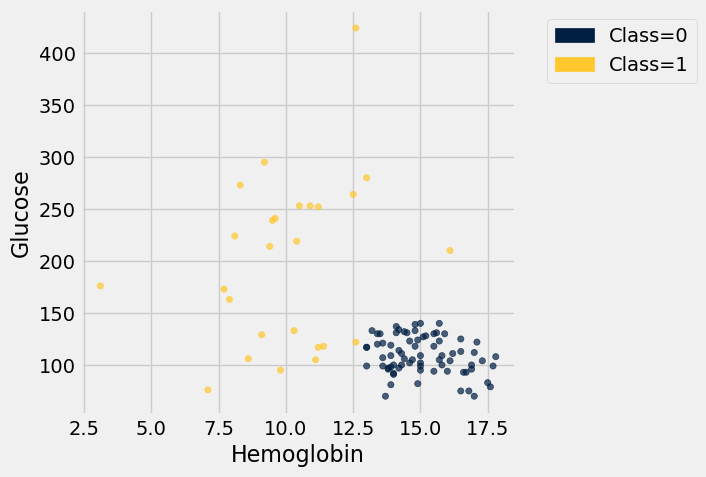

In [11]:
training_set.scatter('Hemoglobin', 'Glucose', group='Class')

In [15]:
min_hemoglobin_for_0 = training_set.where('Class', 0).column('Hemoglobin').min()
max_glucose_for_0 = training_set.where('Class', 0).column('Glucose').max()
min_hemoglobin_for_0, max_glucose_for_0

(13.0, 140)

In [16]:
## Crushed ICE: create a function called classify_manually that takes hemoglobin and glucose values
# and returns a classification of 1 or 0
def classify_manually(hemoglobin, glucose):
    if hemoglobin >= min_hemoglobin_for_0 and glucose <= max_glucose_for_0:
        return 0
    else:
        return 1

In [17]:
classify_manually(15, 100)

0

In [18]:
classify_manually(10, 300)

1

In [21]:
classifications = test_set.select('Hemoglobin', 'Glucose').apply(classify_manually, 0, 1)
classifications

array([1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1,
       1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0])

In [22]:
test_set.column('Class')

array([1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1,
       1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0])

In [24]:
(classifications == test_set.column('Class')).mean()

1.0

## Sometimes 2 dimensions isn't enough

In [26]:
banknotes = Table.read_table('data/banknote.csv')
banknotes.sample()

WaveletVar,WaveletSkew,WaveletCurt,Entropy,Class
-1.3946,2.3134,-0.44499,-1.4905,1
0.66365,-0.045533,-0.18794,0.23447,1
-4.4775,-13.0303,17.0834,-3.0345,1
-2.564,-1.7051,1.5026,0.32757,1
0.83292,7.5404,0.65005,-0.92544,0
-6.1536,7.9295,0.61663,-3.2646,1
2.9543,1.076,0.64577,0.89394,0
-0.39416,-0.020702,-0.066267,-0.44699,1
-0.53966,7.3273,0.46583,-1.4543,0
-3.3924,3.3564,-0.72004,-3.5233,1


In [27]:
banknotes.group('Class')

Class,count
0,762
1,610


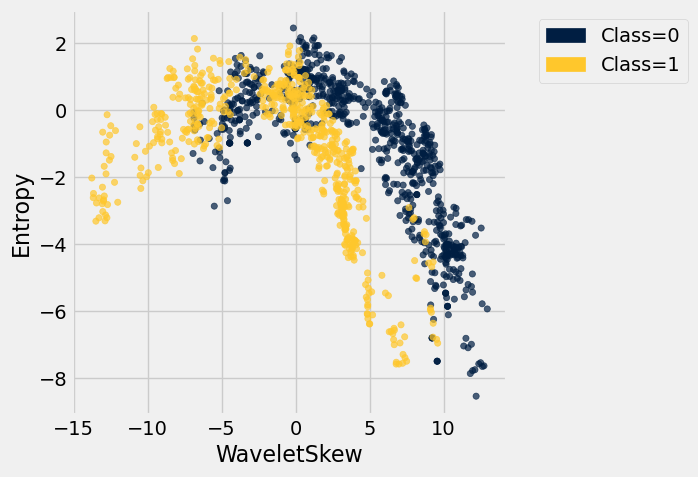

In [28]:
banknotes.scatter('WaveletSkew', 'Entropy', group='Class')

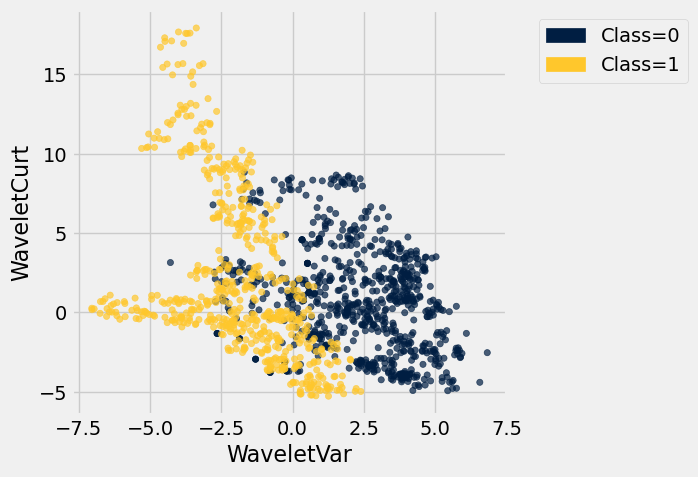

In [29]:
banknotes.scatter('WaveletVar', 'WaveletCurt', group='Class')

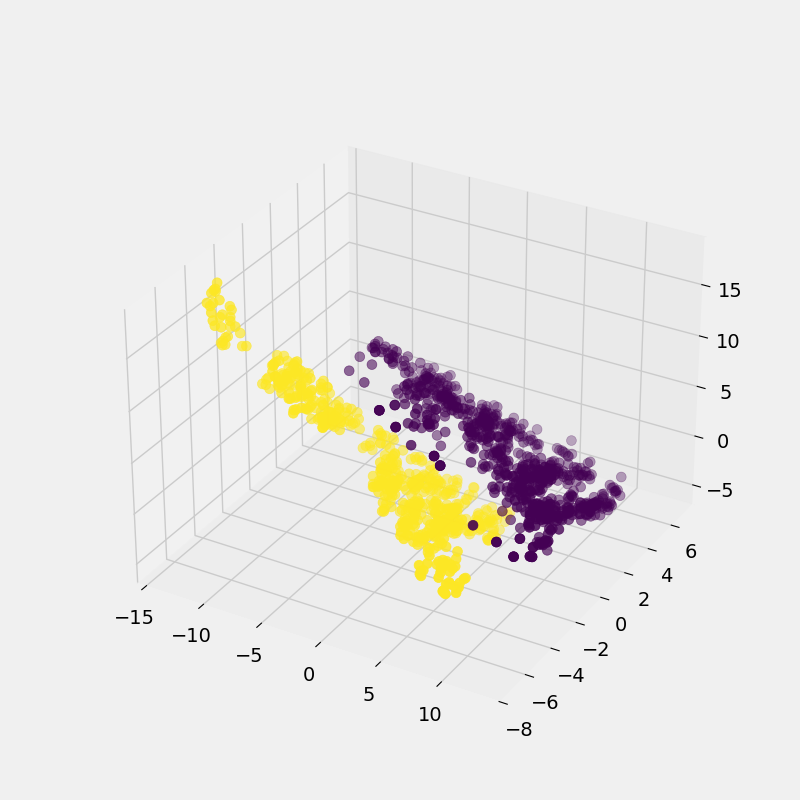

In [30]:
%matplotlib widget
from mpl_toolkits.mplot3d import Axes3D
ax = plt.figure(figsize=(8,8)).add_subplot(111, projection='3d')
ax.scatter(banknotes.column('WaveletSkew'), 
           banknotes.column('WaveletVar'), 
           banknotes.column('WaveletCurt'), 
           c=banknotes.column('Class'),
           cmap='viridis',
          s=50);

# Pre-made nearest neighbor classifier example (k=1)

In [31]:
# don't worry about any of this right now

%matplotlib inline

def standard_units(x):
    return (x - np.mean(x))/np.std(x)

def distance(point1, point2):
    """The distance between two arrays of numbers."""
    return np.sqrt(np.sum((point1 - point2)**2))

def all_distances(training, point):
    """The distance between p (an array of numbers) and the numbers in row i of attribute_table."""
    attributes = training.drop('Class')
    def distance_from_point(row):
        return distance(point, np.array(row))
    return attributes.apply(distance_from_point)

def table_with_distances(training, point):
    """A copy of the training table with the distance from each row to array p."""
    return training.with_column('Distance', all_distances(training, point))

def closest(training, point, k):
    """A table containing the k closest rows in the training table to array p."""
    with_dists = table_with_distances(training, point)
    sorted_by_distance = with_dists.sort('Distance')
    topk = sorted_by_distance.take(np.arange(k))
    return topk

def majority(topkclasses):
    """1 if the majority of the "Class" column is 1s, and 0 otherwise."""
    ones = topkclasses.where('Class', are.equal_to(1)).num_rows
    zeros = topkclasses.where('Class', are.equal_to(0)).num_rows
    if ones > zeros:
        return 1
    else:
        return 0

def classify(training, p, k):
    """Classify an example with attributes p using k-nearest neighbor classification with the given training table."""
    closestk = closest(training, p, k)
    topkclasses = closestk.select('Class')
    return majority(topkclasses)

def show_closest(point):
    """point = array([x,y]) 
    gives the coordinates of a new point
    shown in red"""
    
    HemoGl = ckd.select('Hemoglobin', 'Glucose')
    t = closest(HemoGl, point, 1)
    x_closest = t.row(0).item(0)
    y_closest = t.row(0).item(1)
    ckd.scatter('Hemoglobin', 'Glucose', group='Class')
    plt.scatter(point.item(0), point.item(1), color='red', s=30)
    plt.plot(make_array(point.item(0), x_closest), make_array(point.item(1), y_closest), color='k', lw=2);

def plot_all_points(test_grid):
    test_grid.scatter('Hemoglobin', 'Glucose', color='red', alpha=0.4, s=30)

    plt.scatter(ckd.column('Hemoglobin'), ckd.column('Glucose'), c=ckd.column('Class'), edgecolor='k')

    plt.xlim(-2, 2)
    plt.ylim(-2, 2);
    
def classify_grid(training, test, k):
    c = make_array()
    for i in range(test.num_rows):
        # Run the classifier on the ith patient in the test set
        c = np.append(c, classify(training, make_array(test.row(i)), k))   
    return c

def plot_all_points_classified(test_grid):
    c = classify_grid(ckd.drop('White Blood Cell Count'), test_grid, 1)
    test_grid = test_grid.with_column('Class', c)
    test_grid.scatter('Hemoglobin', 'Glucose', group='Class', alpha=0.4, s=30)
    
    plt.scatter(ckd.column('Hemoglobin'), ckd.column('Glucose'), c=ckd.column('Class'), edgecolor='k')

    plt.xlim(-2, 2)
    plt.ylim(-2, 2);

In [32]:
ckd = Table.read_table('data/ckd.csv').relabeled('Blood Glucose Random', 'Glucose')
ckd = Table().with_columns(
    'Hemoglobin', standard_units(ckd.column('Hemoglobin')),
    'Glucose', standard_units(ckd.column('Glucose')),
    'White Blood Cell Count', standard_units(ckd.column('White Blood Cell Count')),
    'Class', ckd.column('Class')
)

ckd.sample()

Hemoglobin,Glucose,White Blood Cell Count,Class
0.213242,-0.484162,-0.569768,0
1.18781,-0.14431,0.200211,0
0.108824,-0.484162,-0.569768,0
1.22262,-0.669536,-0.794345,0
-1.73589,-0.453267,1.38726,1
0.83975,-0.422371,-1.33975,0
-1.179,0.025616,-0.73018,1
0.14363,-0.793119,-0.216861,0
-1.28342,-0.947597,3.34429,1
-0.0304002,0.0874074,-0.184779,0


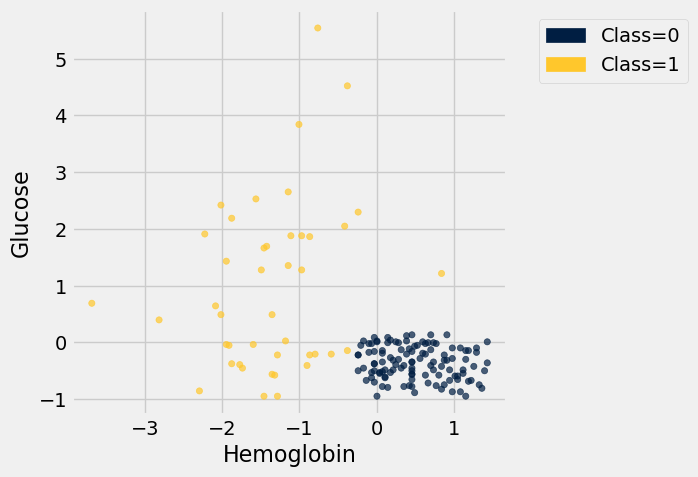

In [34]:
ckd.scatter('Hemoglobin', 'Glucose', group='Class')

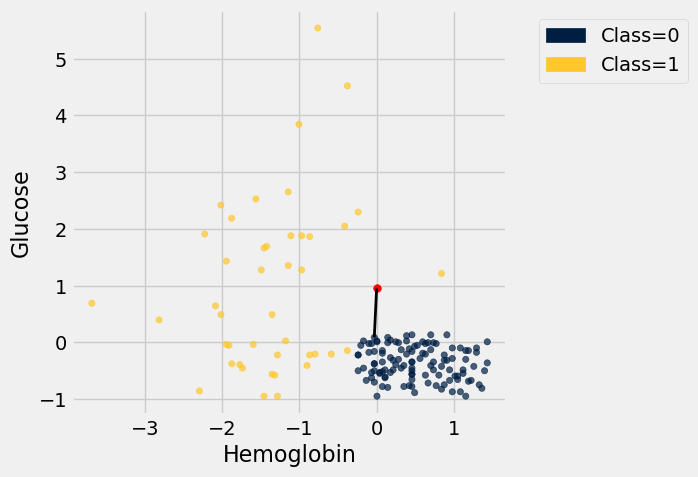

In [35]:
alice = make_array(0, 0.95)
show_closest(alice)

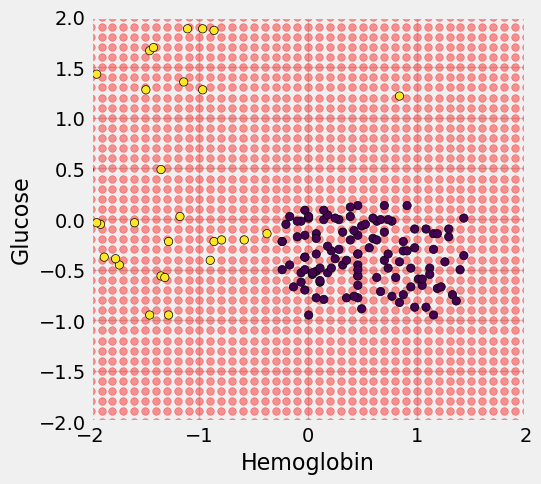

In [36]:
x_array = make_array()
y_array = make_array()
for x in np.arange(-2, 2.1, 0.1):
    for y in np.arange(-2, 2.1, 0.1):
        x_array = np.append(x_array, x)
        y_array = np.append(y_array, y)

test_grid = Table().with_columns(
    'Hemoglobin', x_array,
    'Glucose', y_array
)

plot_all_points(test_grid)

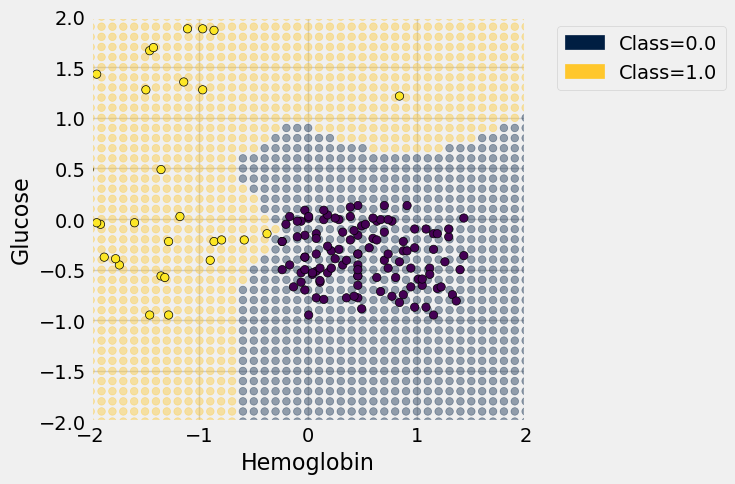

In [37]:
plot_all_points_classified(test_grid)

# k-Nearest Neighbors from scratch this time

## Calculating distance

In [38]:
ckd = Table.read_table('data/ckd.csv').relabeled('Blood Glucose Random', 'Glucose')
ckd = ckd.select('Hemoglobin', 'Glucose', 'Class')
ckd

Hemoglobin,Glucose,Class
11.2,117,1
9.5,70,1
10.8,380,1
5.6,157,1
7.7,173,1
9.8,95,1
12.5,264,1
10,70,1
10.5,253,1
9.8,163,1


In [40]:
alice = make_array(0, 1.1)
alice

array([ 0. ,  1.1])

In [41]:
# Goal: find the distance from Alice to everyone in the dataset

In [42]:
patient1 = ckd.drop('Class').row(0)
patient1

Row(Hemoglobin=11.199999999999999, Glucose=117)

In [43]:
type(patient1)

datascience.tables.Row

In [46]:
((alice.item(0) - patient1.item(0))**2 + (alice.item(1) - patient1.item(1))**2) ** 0.5

116.43989866021012

In [47]:
# ^ if patient1 was an array, this process could be faster!

In [50]:
np.array(patient1)  # make_array doesn't work for conversion

array([  11.2,  117. ])

In [55]:
alice - np.array(patient1)

array([ -11.2, -115.9])

In [56]:
(alice - np.array(patient1)) ** 2

array([   125.44,  13432.81])

In [57]:
np.sum((alice - np.array(patient1)) ** 2)

13558.250000000002

In [58]:
np.sum((alice - np.array(patient1)) ** 2) ** 0.5

116.43989866021012

In [61]:
# Crushed ICE: create a distance(point1, point2) function that returns the distance between
# two points that are represented as arrays
def distance(point1, point2):
    return np.sum((point1 - point2) ** 2) ** 0.5

In [62]:
distance(alice, np.array(patient1))

116.43989866021012

## k-Nearest Neighbors on Alice

In [2]:
ckd = Table.read_table('data/ckd.csv').relabeled('Blood Glucose Random', 'Glucose')
ckd = ckd.select('Hemoglobin', 'Glucose', 'Class')

alice = make_array(0, 1.1)

def distance(point1, point2):
    return np.sum((point1 - point2) ** 2) ** 0.5

In [64]:
ckd

Hemoglobin,Glucose,Class
11.2,117,1
9.5,70,1
10.8,380,1
5.6,157,1
7.7,173,1
9.8,95,1
12.5,264,1
10,70,1
10.5,253,1
9.8,163,1


In [65]:
# Reminder: you can apply a function to an entire table! It passes each Row to the function
t = Table().with_columns('x', make_array(1, 2, 3), 'y', make_array(4, 5, 6))
t

x,y
1,4
2,5
3,6


In [66]:
t.row(0)

Row(x=1, y=4)

In [67]:
type(t.row(0))

datascience.tables.Row

In [68]:
def f(row):
    return row.item(0) - row.item(1)

t.apply(f)

array([-3, -3, -3])

In [5]:
def distance_from_alice(row):
    return distance(alice, np.array(row))

In [70]:
alice

array([ 0. ,  1.1])

In [71]:
ckd # don't want to compare against the Class

Hemoglobin,Glucose,Class
11.2,117,1
9.5,70,1
10.8,380,1
5.6,157,1
7.7,173,1
9.8,95,1
12.5,264,1
10,70,1
10.5,253,1
9.8,163,1


In [6]:
ckd.drop('Class').row(0)

Row(Hemoglobin=11.199999999999999, Glucose=117)

In [7]:
distance_from_alice(ckd.drop('Class').row(0))

116.43989866021012

In [77]:
distances = ckd.drop('Class').apply(distance_from_alice)
distances

array([ 116.43989866,   69.55185116,  379.05388799,  156.00054487,
        172.0723685 ,   94.41001006,  263.19699846,   69.62190747,
        252.11874187,  162.19633165,  128.22332081,  132.3015495 ,
         75.23576277,  279.20281159,  209.5194979 ,  218.14804606,
        294.0439593 ,  117.4545444 ,  223.04712507,  127.16465704,
        117.514297  ,  104.49124365,  287.00874551,  272.02665311,
        121.55480246,  302.07907905,  101.27437978,  106.22476171,
        116.33060646,  238.08960498,   93.42601351,  128.15623278,
        251.14985566,  254.00492121,  252.13571742,  213.1788451 ,
        489.0352339 ,  162.09262784,  240.0920032 ,  213.10741423,
        105.25193585,  423.08766231,  174.92747068,  139.70758748,
         70.96625959,   82.44768038,  118.90151387,   98.75935399,
        120.66884436,  130.70677106,   90.98356995,   97.89187913,
        104.15190829,  130.66300165,  122.08935253,  117.92311054,
        117.02670635,  131.6896731 ,   96.9456033 ,  132.55885

In [ ]:
# Next steps: attach the distances to ckd table, sort, 
# and then take the top k to make a prediction!

---

In [8]:
def all_distances(training, new_row):
    '''Returns an array of distances between each point in the training set
    and the new point (which is a row of attributes)'''
    attributes = training.drop('Class')

    # You can make functions inside other functions! They can use outer variables!
    def distance_from_new_row(row):
        return distance(np.array(new_row), np.array(row))

    return attributes.apply(distance_from_new_row)

In [10]:
distances = all_distances(ckd, alice)
distances

array([ 116.43989866,   69.55185116,  379.05388799,  156.00054487,
        172.0723685 ,   94.41001006,  263.19699846,   69.62190747,
        252.11874187,  162.19633165,  128.22332081,  132.3015495 ,
         75.23576277,  279.20281159,  209.5194979 ,  218.14804606,
        294.0439593 ,  117.4545444 ,  223.04712507,  127.16465704,
        117.514297  ,  104.49124365,  287.00874551,  272.02665311,
        121.55480246,  302.07907905,  101.27437978,  106.22476171,
        116.33060646,  238.08960498,   93.42601351,  128.15623278,
        251.14985566,  254.00492121,  252.13571742,  213.1788451 ,
        489.0352339 ,  162.09262784,  240.0920032 ,  213.10741423,
        105.25193585,  423.08766231,  174.92747068,  139.70758748,
         70.96625959,   82.44768038,  118.90151387,   98.75935399,
        120.66884436,  130.70677106,   90.98356995,   97.89187913,
        104.15190829,  130.66300165,  122.08935253,  117.92311054,
        117.02670635,  131.6896731 ,   96.9456033 ,  132.55885

In [11]:
ckd

Hemoglobin,Glucose,Class
11.2,117,1
9.5,70,1
10.8,380,1
5.6,157,1
7.7,173,1
9.8,95,1
12.5,264,1
10,70,1
10.5,253,1
9.8,163,1


In [13]:
ckd_with_distances = ckd.with_column('Distance from Alice', distances)
ckd_with_distances

Hemoglobin,Glucose,Class,Distance from Alice
11.2,117,1,116.44
9.5,70,1,69.5519
10.8,380,1,379.054
5.6,157,1,156.001
7.7,173,1,172.072
9.8,95,1,94.41
12.5,264,1,263.197
10,70,1,69.6219
10.5,253,1,252.119
9.8,163,1,162.196


In [14]:
ckd_with_distances.sort('Distance from Alice')

Hemoglobin,Glucose,Class,Distance from Alice
9.5,70,1,69.5519
10,70,1,69.6219
13.7,70,0,70.2488
17,70,0,70.9663
15.1,74,0,74.4474
7.1,76,1,75.2358
16.5,75,0,75.7196
16.8,75,0,75.7856
16.1,78,0,78.5673
17.6,79,0,79.8634


In [15]:
ckd_with_distances.sort('Distance from Alice').take(np.arange(5))

Hemoglobin,Glucose,Class,Distance from Alice
9.5,70,1,69.5519
10,70,1,69.6219
13.7,70,0,70.2488
17,70,0,70.9663
15.1,74,0,74.4474


In [16]:
def nearest(training, new_point, k):
    '''Returns a table of the k rows (with distances attached)
    having the smallest distances from the new_point'''
    distances_to_new_point = all_distances(training, new_point)
    with_distances = training.with_column('Distance', distances_to_new_point)
    sorted_by_distances = with_distances.sort('Distance')
    nearest_neighbors_table = sorted_by_distances.take(np.arange(k))
    return nearest_neighbors_table

In [18]:
five_nearest_neighbors = nearest(ckd, alice, 5)
five_nearest_neighbors

Hemoglobin,Glucose,Class,Distance
9.5,70,1,69.5519
10,70,1,69.6219
13.7,70,0,70.2488
17,70,0,70.9663
15.1,74,0,74.4474


In [21]:
ones = five_nearest_neighbors.where('Class', are.equal_to(1)).num_rows
zeros = five_nearest_neighbors.where('Class', are.equal_to(0)).num_rows

if ones > zeros:
    print(1)
else:
    print(0)

0


In [22]:
def majority(nearest_neighbors_table):
    ones = nearest_neighbors_table.where('Class', are.equal_to(1)).num_rows
    zeros = nearest_neighbors_table.where('Class', are.equal_to(0)).num_rows
    
    if ones > zeros:
        return 1
    else:
        return 0

In [23]:
majority(five_nearest_neighbors)

0

In [24]:
def knn(training, new_point, k):
    nearest_neighbors_table = nearest(training, new_point, k)
    return majority(nearest_neighbors_table)

In [25]:
knn(ckd, alice, 5)

0

# k-NN wine example

In [31]:
# distance works no matter the dimensions!

In [32]:
def distance(point1, point2):
    return np.sum((point1 - point2) ** 2) ** 0.5

In [34]:
distance(make_array(1, 2, 3), make_array(4, 5, 6))

5.196152422706632

In [27]:
wine = Table.read_table('data/wine.csv')
wine.sample(10)

Class,Alcohol,Malic Acid,Ash,Alcalinity of Ash,Magnesium,Total Phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color Intensity,Hue,OD280/OD315 of diulted wines,Proline
2,12.42,4.43,2.73,26.5,102,2.2,2.13,0.43,1.71,2.08,0.92,3.12,365
1,13.76,1.53,2.7,19.5,132,2.95,2.74,0.5,1.35,5.4,1.25,3,1235
2,12,1.51,2.42,22,86,1.45,1.25,0.5,1.63,3.6,1.05,2.65,450
2,12.37,1.07,2.1,18.5,88,3.52,3.75,0.24,1.95,4.5,1.04,2.77,660
2,12.17,1.45,2.53,19,104,1.89,1.75,0.45,1.03,2.95,1.45,2.23,355
3,12.58,1.29,2.1,20,103,1.48,0.58,0.53,1.4,7.6,0.58,1.55,640
3,12.82,3.37,2.3,19.5,88,1.48,0.66,0.4,0.97,10.26,0.72,1.75,685
1,14.38,1.87,2.38,12,102,3.3,3.64,0.29,2.96,7.5,1.2,3,1547
1,14.38,1.87,2.38,12,102,3.3,3.64,0.29,2.96,7.5,1.2,3,1547
2,11.56,2.05,3.23,28.5,119,3.18,5.08,0.47,1.87,6,0.93,3.69,465


In [29]:
# we'll focus on class 1 vs. the rest
def is_one(x):
    if x == 1:
        return 1
    else:
        return 0

wine = wine.with_column('Class', wine.apply(is_one, 0))
wine.sample(10)

Class,Alcohol,Malic Acid,Ash,Alcalinity of Ash,Magnesium,Total Phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color Intensity,Hue,OD280/OD315 of diulted wines,Proline
0,11.66,1.88,1.92,16,97,1.61,1.57,0.34,1.15,3.8,1.23,2.14,428
0,12.79,2.67,2.48,22,112,1.48,1.36,0.24,1.26,10.8,0.48,1.47,480
1,13.28,1.64,2.84,15.5,110,2.6,2.68,0.34,1.36,4.6,1.09,2.78,880
1,14.1,2.02,2.4,18.8,103,2.75,2.92,0.32,2.38,6.2,1.07,2.75,1060
0,12.04,4.3,2.38,22,80,2.1,1.75,0.42,1.35,2.6,0.79,2.57,580
1,13.07,1.5,2.1,15.5,98,2.4,2.64,0.28,1.37,3.7,1.18,2.69,1020
0,12.21,1.19,1.75,16.8,151,1.85,1.28,0.14,2.5,2.85,1.28,3.07,718
0,13.49,3.59,2.19,19.5,88,1.62,0.48,0.58,0.88,5.7,0.81,1.82,580
0,11.62,1.99,2.28,18,98,3.02,2.26,0.17,1.35,3.25,1.16,2.96,345
0,12.93,2.81,2.7,21,96,1.54,0.5,0.53,0.75,4.6,0.77,2.31,600


In [30]:
wine.num_columns

14

In [36]:
wine

Class,Alcohol,Malic Acid,Ash,Alcalinity of Ash,Magnesium,Total Phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color Intensity,Hue,OD280/OD315 of diulted wines,Proline
1,14.23,1.71,2.43,15.6,127,2.8,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.2,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.4,1050
1,13.16,2.36,2.67,18.6,101,2.8,3.24,0.3,2.81,5.68,1.03,3.17,1185
1,14.37,1.95,2.5,16.8,113,3.85,3.49,0.24,2.18,7.8,0.86,3.45,1480
1,13.24,2.59,2.87,21,118,2.8,2.69,0.39,1.82,4.32,1.04,2.93,735
1,14.2,1.76,2.45,15.2,112,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450
1,14.39,1.87,2.45,14.6,96,2.5,2.52,0.3,1.98,5.25,1.02,3.58,1290
1,14.06,2.15,2.61,17.6,121,2.6,2.51,0.31,1.25,5.05,1.06,3.58,1295
1,14.83,1.64,2.17,14,97,2.8,2.98,0.29,1.98,5.2,1.08,2.85,1045
1,13.86,1.35,2.27,16,98,2.98,3.15,0.22,1.85,7.22,1.01,3.55,1045


In [37]:
wine_attributes = wine.drop('Class')
distance(np.array(wine_attributes.row(0)), np.array(wine_attributes.row(1))) # both class 1
# ^ the distance function is comparing a ton of values at once!

31.265012394048398

In [38]:
wine.row(177)

Row(Class=0, Alcohol=14.130000000000001, Malic Acid=4.0999999999999996, Ash=2.7400000000000002, Alcalinity of Ash=24.5, Magnesium=96, Total Phenols=2.0499999999999998, Flavanoids=0.76000000000000001, Nonflavanoid phenols=0.56000000000000005, Proanthocyanins=1.3500000000000001, Color Intensity=9.1999999999999993, Hue=0.60999999999999999, OD280/OD315 of diulted wines=1.6000000000000001, Proline=560)

In [39]:
distance(np.array(wine_attributes.row(0)), np.array(wine_attributes.row(177)))
# class 1 vs. class 0

506.05936766351834

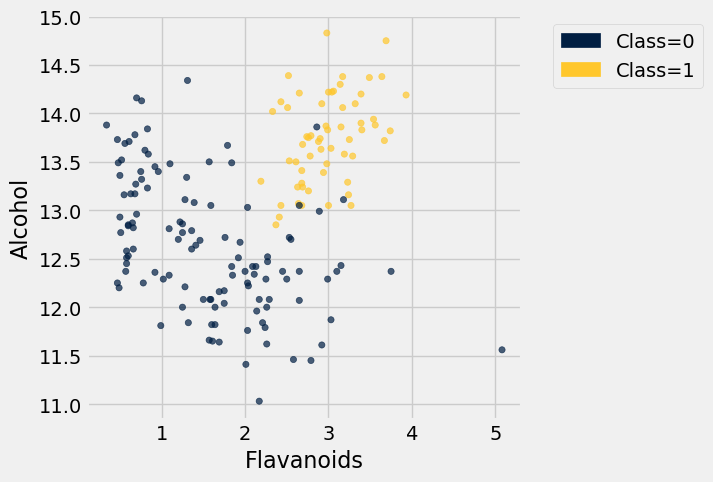

In [40]:
wine.scatter('Flavanoids', 'Alcohol', group='Class')

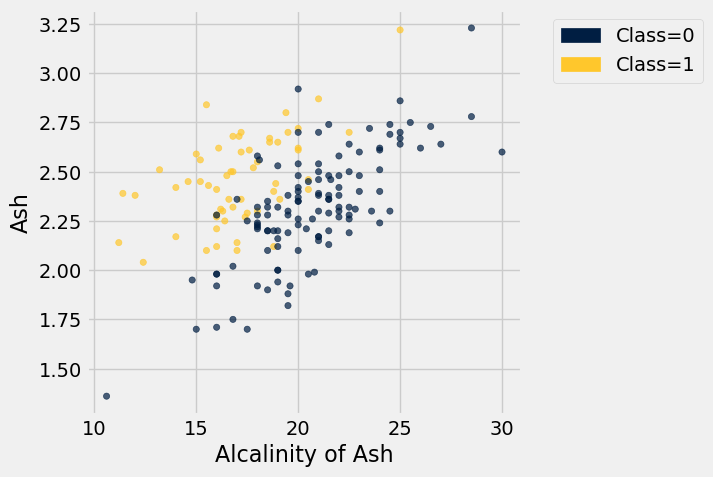

In [41]:
wine.scatter('Alcalinity of Ash', 'Ash', group='Class')

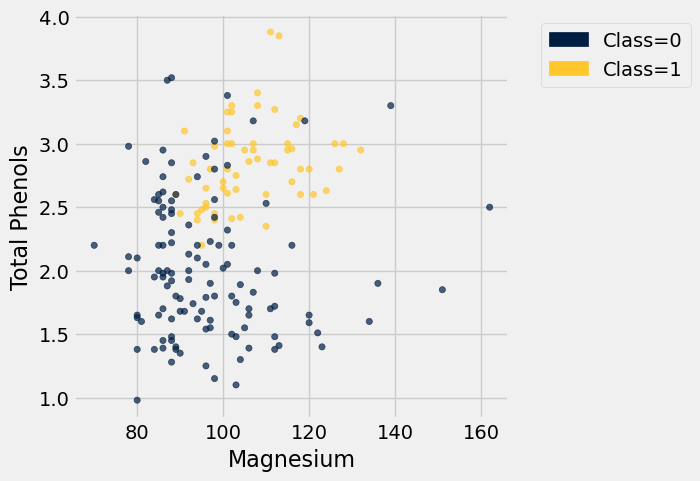

In [42]:
wine.scatter('Magnesium', 'Total Phenols', group='Class')

In [43]:
# ^ lots of overlap, but multiple features/attributes at once (rather than just 2 at a time)
# can often do the trick!

In [44]:
wine.row(0)

Row(Class=1, Alcohol=14.23, Malic Acid=1.71, Ash=2.4300000000000002, Alcalinity of Ash=15.6, Magnesium=127, Total Phenols=2.7999999999999998, Flavanoids=3.0600000000000001, Nonflavanoid phenols=0.28000000000000003, Proanthocyanins=2.29, Color Intensity=5.6399999999999997, Hue=1.04, OD280/OD315 of diulted wines=3.9199999999999999, Proline=1065)

In [45]:
nearest(wine, wine_attributes.row(0), 5)

Class,Alcohol,Malic Acid,Ash,Alcalinity of Ash,Magnesium,Total Phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color Intensity,Hue,OD280/OD315 of diulted wines,Proline,Distance
1,14.23,1.71,2.43,15.6,127,2.8,3.06,0.28,2.29,5.64,1.04,3.92,1065,0
1,13.74,1.67,2.25,16.4,118,2.6,2.9,0.21,1.62,5.85,0.92,3.2,1060,10.3928
1,14.21,4.04,2.44,18.9,111,2.85,2.65,0.3,1.25,5.24,0.87,3.33,1080,22.3407
1,14.1,2.02,2.4,18.8,103,2.75,2.92,0.32,2.38,6.2,1.07,2.75,1060,24.7602
1,14.38,3.59,2.28,16,102,3.25,3.17,0.27,2.19,4.9,1.04,3.44,1065,25.0947


In [46]:
wine.row(177)

Row(Class=0, Alcohol=14.130000000000001, Malic Acid=4.0999999999999996, Ash=2.7400000000000002, Alcalinity of Ash=24.5, Magnesium=96, Total Phenols=2.0499999999999998, Flavanoids=0.76000000000000001, Nonflavanoid phenols=0.56000000000000005, Proanthocyanins=1.3500000000000001, Color Intensity=9.1999999999999993, Hue=0.60999999999999999, OD280/OD315 of diulted wines=1.6000000000000001, Proline=560)

In [47]:
nearest(wine, wine_attributes.row(177), 5)

Class,Alcohol,Malic Acid,Ash,Alcalinity of Ash,Magnesium,Total Phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color Intensity,Hue,OD280/OD315 of diulted wines,Proline,Distance
0,14.13,4.1,2.74,24.5,96,2.05,0.76,0.56,1.35,9.2,0.61,1.6,560,0
0,12.81,2.31,2.4,24,98,1.15,1.09,0.27,0.83,5.7,0.66,1.36,560,4.78493
0,11.65,1.67,2.62,26,88,1.92,1.61,0.4,1.34,2.6,1.36,3.21,562,11.393
0,13.62,4.95,2.35,20,92,2,0.8,0.47,1.02,4.4,0.91,2.05,550,12.6822
0,12.6,1.34,1.9,18.5,88,1.45,1.36,0.29,1.35,2.45,1.04,2.77,562,12.7504


## Evaluating the classifier's accuracy

In [49]:
wine.num_rows / 2

89.0

In [51]:
wine # we better shuffle first!

Class,Alcohol,Malic Acid,Ash,Alcalinity of Ash,Magnesium,Total Phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color Intensity,Hue,OD280/OD315 of diulted wines,Proline
1,14.23,1.71,2.43,15.6,127,2.8,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.2,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.4,1050
1,13.16,2.36,2.67,18.6,101,2.8,3.24,0.3,2.81,5.68,1.03,3.17,1185
1,14.37,1.95,2.5,16.8,113,3.85,3.49,0.24,2.18,7.8,0.86,3.45,1480
1,13.24,2.59,2.87,21,118,2.8,2.69,0.39,1.82,4.32,1.04,2.93,735
1,14.2,1.76,2.45,15.2,112,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450
1,14.39,1.87,2.45,14.6,96,2.5,2.52,0.3,1.98,5.25,1.02,3.58,1290
1,14.06,2.15,2.61,17.6,121,2.6,2.51,0.31,1.25,5.05,1.06,3.58,1295
1,14.83,1.64,2.17,14,97,2.8,2.98,0.29,1.98,5.2,1.08,2.85,1045
1,13.86,1.35,2.27,16,98,2.98,3.15,0.22,1.85,7.22,1.01,3.55,1045


In [54]:
shuffled_wine = wine.sample(with_replacement=False)
training_set = shuffled_wine.take(np.arange(89))
test_set = shuffled_wine.take(np.arange(89, 178))

In [55]:
training_set

Class,Alcohol,Malic Acid,Ash,Alcalinity of Ash,Magnesium,Total Phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color Intensity,Hue,OD280/OD315 of diulted wines,Proline
1,13.74,1.67,2.25,16.4,118,2.6,2.9,0.21,1.62,5.85,0.92,3.2,1060
0,13.67,1.25,1.92,18,94,2.1,1.79,0.32,0.73,3.8,1.23,2.46,630
1,12.85,1.6,2.52,17.8,95,2.48,2.37,0.26,1.46,3.93,1.09,3.63,1015
0,12.72,1.75,2.28,22.5,84,1.38,1.76,0.48,1.63,3.3,0.88,2.42,488
0,12.96,3.45,2.35,18.5,106,1.39,0.7,0.4,0.94,5.28,0.68,1.75,675
0,12.51,1.73,1.98,20.5,85,2.2,1.92,0.32,1.48,2.94,1.04,3.57,672
0,14.13,4.1,2.74,24.5,96,2.05,0.76,0.56,1.35,9.2,0.61,1.6,560
1,14.38,1.87,2.38,12,102,3.3,3.64,0.29,2.96,7.5,1.2,3,1547
1,13.51,1.8,2.65,19,110,2.35,2.53,0.29,1.54,4.2,1.1,2.87,1095
0,13.73,4.36,2.26,22.5,88,1.28,0.47,0.52,1.15,6.62,0.78,1.75,520


In [56]:
test_set

Class,Alcohol,Malic Acid,Ash,Alcalinity of Ash,Magnesium,Total Phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color Intensity,Hue,OD280/OD315 of diulted wines,Proline
0,12.2,3.03,2.32,19,96,1.25,0.49,0.4,0.73,5.5,0.66,1.83,510
1,12.93,3.8,2.65,18.6,102,2.41,2.41,0.25,1.98,4.5,1.03,3.52,770
0,12.69,1.53,2.26,20.7,80,1.38,1.46,0.58,1.62,3.05,0.96,2.06,495
0,11.03,1.51,2.2,21.5,85,2.46,2.17,0.52,2.01,1.9,1.71,2.87,407
1,13.76,1.53,2.7,19.5,132,2.95,2.74,0.5,1.35,5.4,1.25,3,1235
0,11.41,0.74,2.5,21,88,2.48,2.01,0.42,1.44,3.08,1.1,2.31,434
1,13.56,1.71,2.31,16.2,117,3.15,3.29,0.34,2.34,6.13,0.95,3.38,795
1,14.23,1.71,2.43,15.6,127,2.8,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,14.12,1.48,2.32,16.8,95,2.2,2.43,0.26,1.57,5,1.17,2.82,1280
0,12.37,1.21,2.56,18.1,98,2.42,2.65,0.37,2.08,4.6,1.19,2.3,678


In [58]:
# we can use == on arrays to test the original classes against the classifier's best guess
make_array(0, 1, 0) == make_array(0, 1, 1)

array([ True,  True, False], dtype=bool)

In [60]:
np.count_nonzero(make_array(0, 1, 0) == make_array(0, 1, 1)) / 3

0.6666666666666666

In [61]:
# Goal: make this function: evaluate_accuracy(training_set, test_set, 5)

In [65]:
test_set

Class,Alcohol,Malic Acid,Ash,Alcalinity of Ash,Magnesium,Total Phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color Intensity,Hue,OD280/OD315 of diulted wines,Proline
0,12.2,3.03,2.32,19,96,1.25,0.49,0.4,0.73,5.5,0.66,1.83,510
1,12.93,3.8,2.65,18.6,102,2.41,2.41,0.25,1.98,4.5,1.03,3.52,770
0,12.69,1.53,2.26,20.7,80,1.38,1.46,0.58,1.62,3.05,0.96,2.06,495
0,11.03,1.51,2.2,21.5,85,2.46,2.17,0.52,2.01,1.9,1.71,2.87,407
1,13.76,1.53,2.7,19.5,132,2.95,2.74,0.5,1.35,5.4,1.25,3,1235
0,11.41,0.74,2.5,21,88,2.48,2.01,0.42,1.44,3.08,1.1,2.31,434
1,13.56,1.71,2.31,16.2,117,3.15,3.29,0.34,2.34,6.13,0.95,3.38,795
1,14.23,1.71,2.43,15.6,127,2.8,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,14.12,1.48,2.32,16.8,95,2.2,2.43,0.26,1.57,5,1.17,2.82,1280
0,12.37,1.21,2.56,18.1,98,2.42,2.65,0.37,2.08,4.6,1.19,2.3,678


In [64]:
test_attributes = test_set.drop('Class')

In [66]:
knn(training_set, test_attributes.row(0), 5)

0

In [68]:
def classify_test_row(row):
    return knn(training_set, row, 5)

test_attributes.apply(classify_test_row) == test_set.column('Class')

array([ True, False,  True,  True,  True,  True, False,  True,  True,
        True,  True,  True,  True,  True, False,  True, False,  True,
        True,  True,  True,  True,  True, False,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True, False,  True,  True,  True,  True,  True,  True,  True,
        True,  True, False,  True, False,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True, False,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True], dtype=bool)

In [70]:
np.count_nonzero(test_attributes.apply(classify_test_row) == test_set.column('Class')) / test_set.num_rows

0.898876404494382

In [71]:
def evaluate_accuracy(training, test, k):
    test_attributes = test.drop('Class')

    def classify_test_row(row):
        return knn(training, row, k)
    
    predicted_classes = test_attributes.apply(classify_test_row)
    return np.count_nonzero(predicted_classes == test.column('Class')) / test.num_rows

In [72]:
evaluate_accuracy(training_set, test_set, 5)

0.898876404494382

# Breast cancer example

In [74]:
patients = Table.read_table('data/breast-cancer.csv').drop('ID')
patients.sample(10)

Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
5,1,3,3,2,2,2,3,1,0
10,4,3,10,3,10,7,1,2,1
1,1,1,1,2,1,2,1,1,0
3,7,7,4,4,9,4,8,1,1
4,8,6,3,4,10,7,1,1,1
3,1,1,1,2,5,1,1,1,0
3,1,1,1,1,1,2,1,1,0
1,1,1,1,2,1,2,1,1,0
5,1,1,1,2,1,1,1,1,0
1,1,1,1,2,1,3,1,1,0


In [75]:
patients.num_columns

10

In [77]:
patients.num_rows

683

In [78]:
patients.group('Class')

Class,count
0,444
1,239


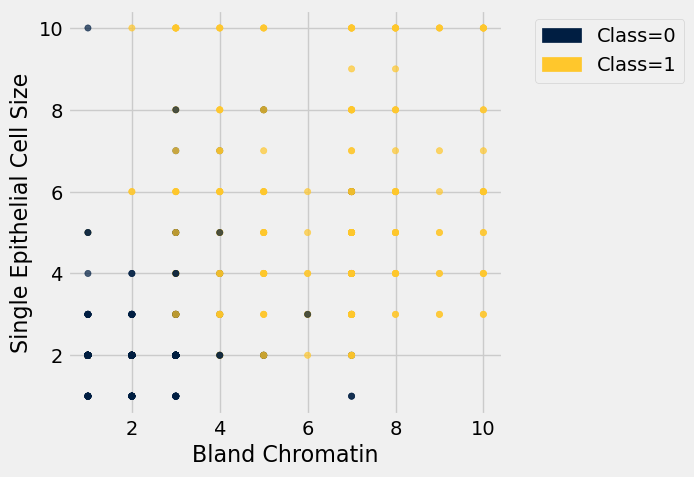

In [80]:
patients.scatter('Bland Chromatin', 'Single Epithelial Cell Size', group='Class')
# A bunch of dots overlap! This is called overplotting

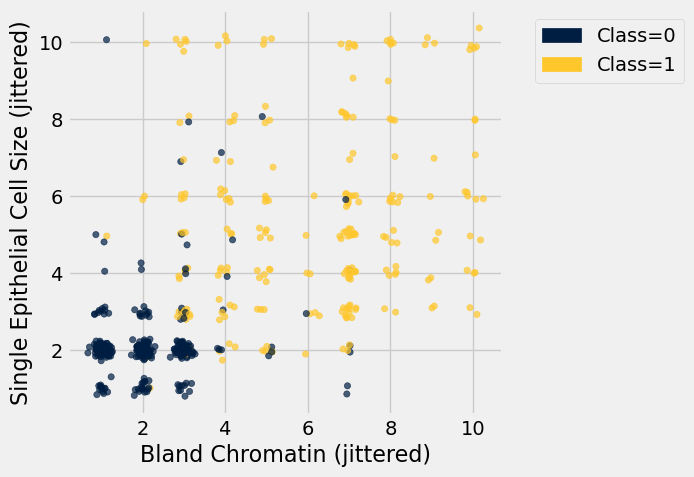

In [81]:
def randomize_column(a):
    return a + np.random.normal(0.0, 0.1, size=len(a))

jittered = Table().with_columns([
        'Bland Chromatin (jittered)', 
        randomize_column(patients.column('Bland Chromatin')),
        'Single Epithelial Cell Size (jittered)', 
        randomize_column(patients.column('Single Epithelial Cell Size')),
        'Class',
        patients.column('Class')
    ])

jittered.scatter(0, 1, group='Class')

In [82]:
# Crushed ICE: shuffle the patients table, make a 50/50 for the training/test sets,
# and evaluate a 5-NN classifier

In [83]:
683 / 2

341.5

In [85]:
patients.num_rows

683

In [87]:
shuffled_patients = patients.sample(683, with_replacement=False)
training_set = shuffled_patients.take(np.arange(342))
test_set = shuffled_patients.take(np.arange(342, 683))

In [88]:
evaluate_accuracy(training_set, test_set, 5)

0.9736070381231672

---